# Analysis: Pre-AI vs Post-AI Infrastructure Outage Media Framing

Name: Zehan Li

Analysis:

Three analyses:
1. **Sentiment Analysis** — VADER + TextBlob
2. **TF-IDF Vocabulary Comparison** — distinctive words per era
3. **Agency Analysis** — blame attribution patterns

Primary data: Guardian full-text articles. NYT headlines as robustness check.

AI Using: Used for VADER checking, tfidf and agency did indivudually

In [6]:
# CELL 1: Setup & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# CHANGE THIS to your actual path
BASE_DATA = "/Users/zehanli/Course_Uchicago/Winter_2025/MACS30122/final-project-error-502/data"
OUT_DIR = f"{BASE_DATA}/analysis&visualization"
os.makedirs(OUT_DIR, exist_ok=True)

# Load merged data
df_all = pd.read_csv(f"{BASE_DATA}/merged_relevant_articles.csv")
df_all["pub_date"] = pd.to_datetime(df_all["pub_date"], utc=True, errors="coerce")

# Guardian full-text subset (primary analysis)
df_gd = df_all[(df_all["source"] == "guardian") & (df_all["has_full_text"] == True)].copy()

# NYT subset (robustness check on titles)
df_nyt = df_all[df_all["source"] == "nyt"].copy()

print(f"Guardian full-text articles: {len(df_gd)}")
print(f"  Pre-AI: {len(df_gd[df_gd['era']=='pre_ai'])}")
print(f"  Post-AI: {len(df_gd[df_gd['era']=='post_ai'])}")
print(f"\nNYT articles: {len(df_nyt)}")
print(f"  Pre-AI: {len(df_nyt[df_nyt['era']=='pre_ai'])}")
print(f"  Post-AI: {len(df_nyt[df_nyt['era']=='post_ai'])}")


Guardian full-text articles: 269
  Pre-AI: 138
  Post-AI: 131

NYT articles: 53
  Pre-AI: 23
  Post-AI: 30


In [7]:
haugen_keywords = ["haugen", "whistleblower", "testimony", "hearing", 
                   "misinformation", "internal documents", "facebook files",
                   "content moderation", "teen", "mental health"]

def is_outage_focused(row):
    """Check if article is primarily about the outage, not Haugen."""
    if row["event"] != "facebook_2021":
        return True
    text = str(row["text_for_analysis"]).lower()
    title = str(row["title"]).lower()
    # Title must mention outage-related terms
    outage_in_title = any(w in title for w in ["outage", "down", "offline", "disruption"])
    # Not dominated by Haugen content
    haugen_heavy = sum(text.count(kw) for kw in haugen_keywords) > 5
    return outage_in_title or not haugen_heavy

df_gd["outage_focused"] = df_gd.apply(is_outage_focused, axis=1)
print(f"Before: {len(df_gd)}")
df_gd_clean = df_gd[df_gd["outage_focused"]].copy()
print(f"After filtering Haugen noise: {len(df_gd_clean)}")
print(df_gd_clean.groupby(["era", "event"]).size())
df_gd = df_gd = df_gd_clean.copy()


Before: 269
After filtering Haugen noise: 230
era      event            
post_ai  aws_2025             28
         azure_2025            2
         crowdstrike_2024     54
         google_cloud_2025    47
pre_ai   aws_2021              1
         facebook_2021        75
         fastly_2021          18
         google_2020           5
dtype: int64


---
## 1. Sentiment Analysis

Using both VADER (rule-based, good for news) and TextBlob (pattern-based) for robustness.

In [8]:
!pip install vaderSentiment
!pip install textblob


In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

vader = SentimentIntensityAnalyzer()


def get_sentiment(text):
    """Return VADER compound + TextBlob polarity & subjectivity."""
    text = str(text)
    v = vader.polarity_scores(text)
    tb = TextBlob(text)
    return pd.Series({
        "vader_compound": v["compound"],
        "vader_pos": v["pos"],
        "vader_neg": v["neg"],
        "vader_neu": v["neu"],
        "tb_polarity": tb.sentiment.polarity,
        "tb_subjectivity": tb.sentiment.subjectivity,
    })


SENT_COLS = [
    "vader_compound", "vader_pos", "vader_neg", "vader_neu",
    "tb_polarity", "tb_subjectivity",
]


def recompute_sentiment(df, text_col, label):
    """Idempotent sentiment computation: drop old sentiment cols, then recompute."""
    df = df.drop(columns=[c for c in SENT_COLS if c in df.columns], errors="ignore")
    sent = df[text_col].fillna("").astype(str).apply(get_sentiment)
    df = pd.concat([df.reset_index(drop=True), sent.reset_index(drop=True)], axis=1)
    dup_cols = [c for c in df.columns if df.columns.tolist().count(c) > 1]
    print(f"{label}: {len(df)} rows, duplicate cols={dup_cols}")
    return df


print("Computing sentiment (idempotent)...")
df_gd = recompute_sentiment(df_gd, "text_for_analysis", "Guardian (full text)")
df_nyt = recompute_sentiment(df_nyt, "title", "NYT (title)")
print("Done.")


Computing sentiment (idempotent)...
Guardian (full text): 230 rows, duplicate cols=[]
NYT (title): 53 rows, duplicate cols=[]
Done.


In [10]:
# 方案：对Guardian文章只取前3段做sentiment（模拟lead/framing段落）
# 这既避免VADER饱和，又更focused——新闻的framing主要在前几段

def get_lead_text(text, n_sentences=5):
    """Extract first n sentences as lead."""
    text = str(text)
    sentences = text.split('.')[:n_sentences]
    return '.'.join(sentences)

df_gd["lead_text"] = df_gd["text_for_analysis"].apply(lambda t: get_lead_text(t, 5))

# Recompute sentiment on lead only
lead_sent = df_gd["lead_text"].apply(get_sentiment)
lead_sent.columns = [f"lead_{c}" for c in lead_sent.columns]
df_gd = pd.concat([df_gd.reset_index(drop=True), lead_sent.reset_index(drop=True)], axis=1)

# Compare
print("=== VADER on Lead (first 5 sentences) ===")
print(df_gd.groupby("era")["lead_vader_compound"].agg(["mean", "median", "std"]).round(4))


=== VADER on Lead (first 5 sentences) ===
           mean  median     std
era                            
post_ai -0.0766 -0.1744  0.7556
pre_ai  -0.0262  0.0000  0.6841


In [11]:
print("=" * 60)
print("GUARDIAN — Sentiment by Era (full text)")
print("=" * 60)

sent_cols = ["vader_compound", "tb_polarity", "tb_subjectivity"]

for col in sent_cols:
    print(f"\n--- {col} ---")
    summary = df_gd.groupby("era")[col].agg(["mean", "median", "std", "count"])
    print(summary.round(4))

    # Statistical test: Mann-Whitney U (non-parametric, doesn't assume normality)
    pre = df_gd[df_gd["era"] == "pre_ai"][col].dropna()
    post = df_gd[df_gd["era"] == "post_ai"][col].dropna()
    u_stat, p_val = stats.mannwhitneyu(pre, post, alternative="two-sided")
    print(f"  Mann-Whitney U: U={float(u_stat):.1f}, p={float(p_val):.4f} {'***' if float(p_val) < 0.001 else '**' if float(p_val) < 0.01 else '*' if float(p_val) < 0.05 else 'n.s.'}")


print("\n" + "=" * 60)
print("GUARDIAN — Sentiment by Event")
print("=" * 60)
print(df_gd.groupby(["era", "event"])[sent_cols].agg(["mean", "count"]).round(4))


GUARDIAN — Sentiment by Era (full text)

--- vader_compound ---
           mean  median     std  count
era                                   
post_ai  0.1234  0.6404  0.9101    131
pre_ai   0.1127  0.6855  0.9130     99
  Mann-Whitney U: U=6439.0, p=0.9282 n.s.

--- tb_polarity ---
           mean  median     std  count
era                                   
post_ai  0.0732  0.0704  0.0641    131
pre_ai   0.0759  0.0731  0.0488     99
  Mann-Whitney U: U=6674.0, p=0.7052 n.s.

--- tb_subjectivity ---
           mean  median     std  count
era                                   
post_ai  0.4235  0.4264  0.0619    131
pre_ai   0.4295  0.4276  0.0548     99
  Mann-Whitney U: U=6733.0, p=0.6197 n.s.

GUARDIAN — Sentiment by Event
                          vader_compound       tb_polarity        \
                                    mean count        mean count   
era     event                                                      
post_ai aws_2025                  0.0662    28      0.0583   

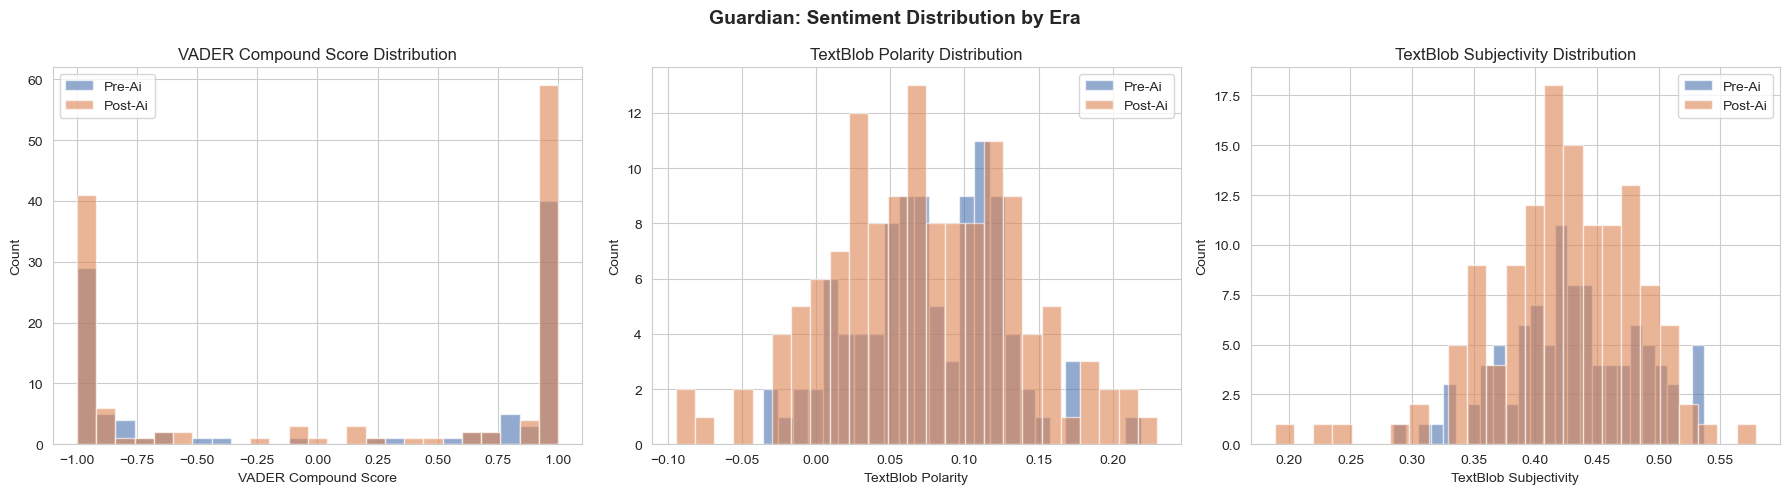

Saved: fig_sentiment_distributions.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("vader_compound", "VADER Compound Score"),
    ("tb_polarity", "TextBlob Polarity"),
    ("tb_subjectivity", "TextBlob Subjectivity"),
]

colors = {"pre_ai": "#4C72B0", "post_ai": "#DD8452"}

for ax, (col, label) in zip(axes, metrics):
    for era in ["pre_ai", "post_ai"]:
        data = df_gd[df_gd["era"] == era][col].dropna()
        ax.hist(data, bins=25, alpha=0.6, label=era.replace("_", "-").title(),
                color=colors[era], edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title(f"{label} Distribution")

plt.suptitle("Guardian: Sentiment Distribution by Era", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_sentiment_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_sentiment_distributions.png")


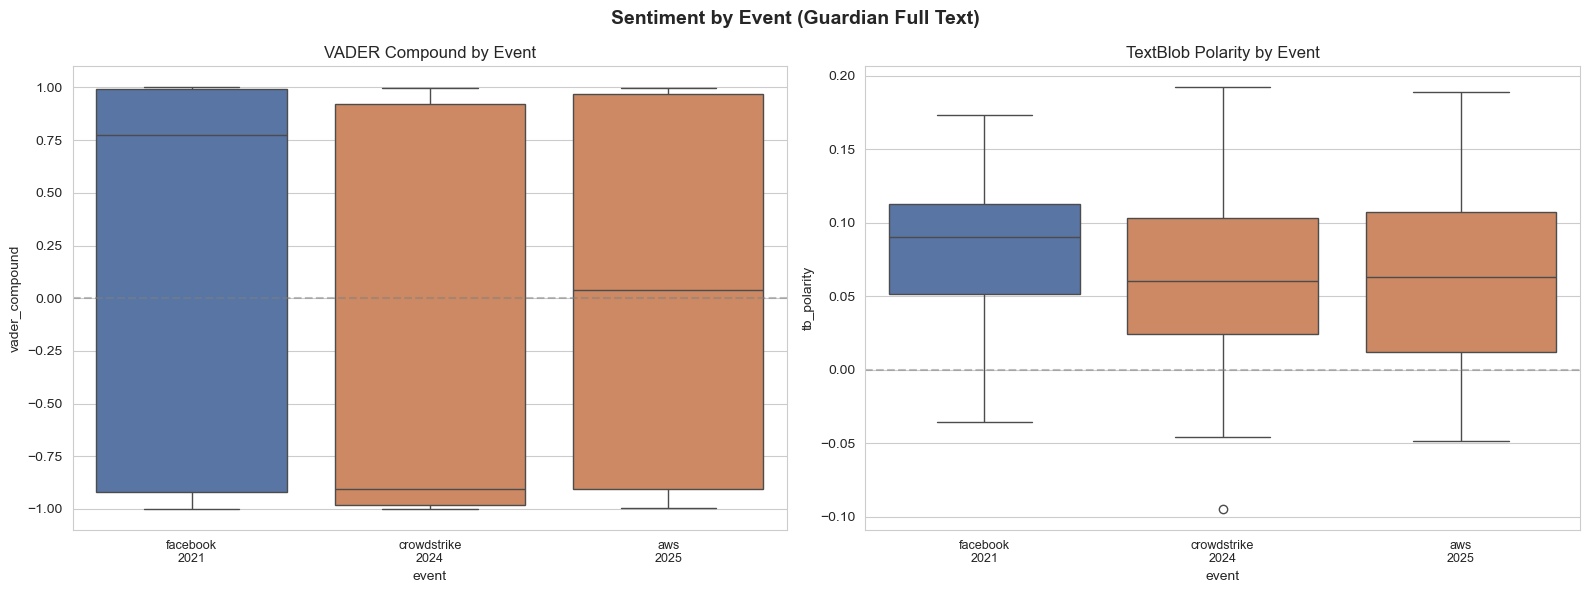

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VADER by event
order = ["cloudflare_2019", "facebook_2021", "crowdstrike_2024", "aws_2025", "cloudflare_2025"]
order = [e for e in order if e in df_gd["event"].unique()]  # keep only events present

palette = {e: colors["pre_ai"] if "2019" in e or "2021" in e else colors["post_ai"] for e in order}

sns.boxplot(data=df_gd, x="event", y="vader_compound", order=order,
            palette=palette, ax=axes[0])
axes[0].set_title("VADER Compound by Event")
axes[0].set_xticklabels([e.replace("_", "\n") for e in order], fontsize=9)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# TextBlob polarity by event
sns.boxplot(data=df_gd, x="event", y="tb_polarity", order=order,
            palette=palette, ax=axes[1])
axes[1].set_title("TextBlob Polarity by Event")
axes[1].set_xticklabels([e.replace("_", "\n") for e in order], fontsize=9)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

plt.suptitle("Sentiment by Event (Guardian Full Text)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_sentiment_by_event.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
print("=" * 60)
print("NYT — Title Sentiment by Era (Robustness Check)")
print("=" * 60)

for col in ["vader_compound", "tb_polarity"]:
    print(f"\n--- {col} ---")
    summary = df_nyt.groupby("era")[col].agg(["mean", "median", "std", "count"])
    print(summary.round(4))

    pre = df_nyt[df_nyt["era"] == "pre_ai"][col].dropna()
    post = df_nyt[df_nyt["era"] == "post_ai"][col].dropna()
    if len(pre) > 0 and len(post) > 0:
        u_stat, p_val = stats.mannwhitneyu(pre, post, alternative="two-sided")
        print(f"  Mann-Whitney U: U={u_stat:.1f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'}")


NYT — Title Sentiment by Era (Robustness Check)

--- vader_compound ---
           mean  median     std  count
era                                   
post_ai -0.1183     0.0  0.2875     30
pre_ai  -0.1606     0.0  0.3043     23
  Mann-Whitney U: U=310.0, p=0.5128 n.s.

--- tb_polarity ---
           mean  median     std  count
era                                   
post_ai -0.0120     0.0  0.1600     30
pre_ai  -0.0966     0.0  0.1676     23
  Mann-Whitney U: U=256.0, p=0.0682 n.s.


---
## 2. TF-IDF Vocabulary Comparison

What words distinguish Pre-AI vs Post-AI outage coverage?

In [15]:
print(f"df_gd rows: {len(df_gd)}")
print(df_gd.groupby(["era", "event"]).size())


df_gd rows: 230
era      event            
post_ai  aws_2025             28
         azure_2025            2
         crowdstrike_2024     54
         google_cloud_2025    47
pre_ai   aws_2021              1
         facebook_2021        75
         fastly_2021          18
         google_2020           5
dtype: int64


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Event-specific proper nouns to exclude
# These tell us WHICH company had an outage, not HOW media frames it
event_stopwords = [
    # Facebook/Meta
    "facebook", "facebook's", "instagram", "whatsapp", "meta", "meta's",
    "zuckerberg", "mark zuckerberg", "haugen", "frances haugen",
    "clegg", "nick clegg", "metaverse", "messenger",
    # CrowdStrike
    "crowdstrike", "crowdstrike's", "george kurtz", "kurtz",
    # Cloudflare
    "cloudflare", "cloudflare's", "matthew prince", "prince",
    # AWS/Amazon
    "amazon", "amazon's", "aws", "bezos", "jeff bezos",
    # Microsoft (involved in CrowdStrike)
    "microsoft", "microsoft's", "windows", "satya nadella",
    # Generic company/platform names that leak event identity
    "delta", "delta airlines",
]

# Prepare corpus
pre_texts = df_gd[df_gd["era"] == "pre_ai"]["text_for_analysis"].tolist()
post_texts = df_gd[df_gd["era"] == "post_ai"]["text_for_analysis"].tolist()
corpus = pre_texts + post_texts
labels = ["pre_ai"] * len(pre_texts) + ["post_ai"] * len(post_texts)

# Build custom stop words list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stops = list(ENGLISH_STOP_WORDS) + event_stopwords

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=custom_stops,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)

tfidf_matrix = tfidf.fit_transform(corpus)
feature_names = tfidf.get_feature_names_out()

print(f"Corpus: {len(pre_texts)} pre-AI + {len(post_texts)} post-AI = {len(corpus)} docs")
print(f"Vocabulary size (after removing event names): {len(feature_names)}")


Corpus: 99 pre-AI + 131 post-AI = 230 docs
Vocabulary size (after removing event names): 5000


In [17]:
pre_mask = [l == "pre_ai" for l in labels]
post_mask = [l == "post_ai" for l in labels]

pre_mean = np.array(tfidf_matrix[pre_mask].mean(axis=0)).flatten()
post_mean = np.array(tfidf_matrix[post_mask].mean(axis=0)).flatten()

diff = post_mean - pre_mean

df_tfidf = pd.DataFrame({
    "word": feature_names,
    "pre_ai_mean": pre_mean,
    "post_ai_mean": post_mean,
    "diff": diff,
    "abs_diff": np.abs(diff),
})

n_top = 25

print("=" * 60)
print(f"TOP {n_top} DISTINCTIVE WORDS — POST-AI ERA")
print("(event names removed — these reflect FRAMING differences)")
print("=" * 60)
top_post = df_tfidf.nlargest(n_top, "diff")
for _, row in top_post.iterrows():
    bar = "█" * int(row["diff"] * 800)
    print(f"  {row['word']:30s} +{row['diff']:.4f}  {bar}")

print(f"\n{'=' * 60}")
print(f"TOP {n_top} DISTINCTIVE WORDS — PRE-AI ERA")
print("(event names removed — these reflect FRAMING differences)")
print("=" * 60)
top_pre = df_tfidf.nsmallest(n_top, "diff")
for _, row in top_pre.iterrows():
    bar = "█" * int(abs(row["diff"]) * 800)
    print(f"  {row['word']:30s} -{abs(row['diff']):.4f}  {bar}")


TOP 25 DISTINCTIVE WORDS — POST-AI ERA
(event names removed — these reflect FRAMING differences)
  ai                             +0.0350  ███████████████████████████
  said                           +0.0229  ██████████████████
  update                         +0.0188  ███████████████
  cloud                          +0.0188  ███████████████
  flights                        +0.0167  █████████████
  friday                         +0.0160  ████████████
  systems                        +0.0151  ████████████
  airlines                       +0.0135  ██████████
  customers                      +0.0132  ██████████
  software                       +0.0132  ██████████
  cancelled                      +0.0127  ██████████
  airport                        +0.0122  █████████
  passengers                     +0.0119  █████████
  cybersecurity                  +0.0117  █████████
  cyber                          +0.0112  ████████
  services                       +0.0104  ████████
  airports          

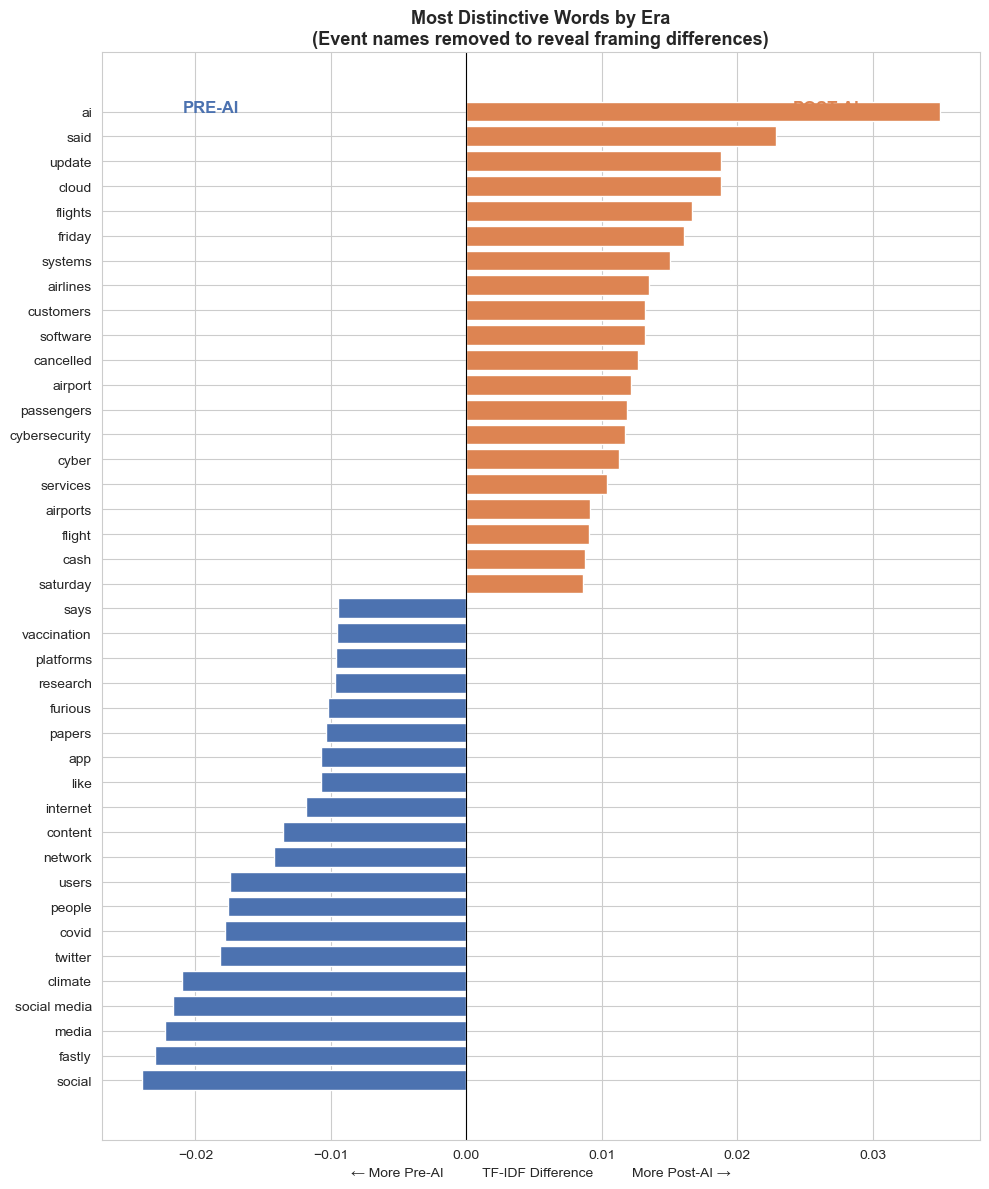

Saved: fig_tfidf_distinctive_words_clean.png


In [18]:
n_show = 20
top_post_viz = df_tfidf.nlargest(n_show, "diff")
top_pre_viz = df_tfidf.nsmallest(n_show, "diff")
viz_data = pd.concat([top_pre_viz, top_post_viz]).sort_values("diff")

fig, ax = plt.subplots(figsize=(10, 12))
bar_colors = ["#4C72B0" if d < 0 else "#DD8452" for d in viz_data["diff"]]
ax.barh(viz_data["word"], viz_data["diff"], color=bar_colors, edgecolor="white")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("← More Pre-AI          TF-IDF Difference          More Post-AI →")
ax.set_title("Most Distinctive Words by Era\n(Event names removed to reveal framing differences)",
             fontsize=13, fontweight="bold")

ax.text(ax.get_xlim()[0] * 0.7, len(viz_data) - 1, "PRE-AI", fontsize=12,
        color="#4C72B0", fontweight="bold", ha="center")
ax.text(ax.get_xlim()[1] * 0.7, len(viz_data) - 1, "POST-AI", fontsize=12,
        color="#DD8452", fontweight="bold", ha="center")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_tfidf_distinctive_words_clean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_tfidf_distinctive_words_clean.png")


In [19]:
framing_categories = {
    "AI/Tech Complexity": ["ai", "artificial intelligence", "algorithm", "machine learning",
                           "automated", "automation", "model", "neural", "chatgpt", "openai"],
    "Risk/Safety": ["risk", "safety", "danger", "threat", "vulnerable", "vulnerability",
                    "catastroph", "critical", "severe", "devastating"],
    "Regulation/Policy": ["regulation", "regulate", "policy", "government", "congress",
                          "legislation", "oversight", "accountability", "compliance", "law"],
    "Infrastructure/System": ["infrastructure", "system", "server", "network", "cloud",
                              "data center", "backbone", "dns", "bgp", "routing"],
    "Human Error": ["mistake", "error", "human error", "misconfiguration", "accidentally",
                    "bug", "fault", "flaw", "blunder"],
    "Economic Impact": ["cost", "billion", "million", "economic", "financial", "loss",
                        "revenue", "stock", "lawsuit", "compensation"],
}

def count_keywords(text, keywords):
    """Count keyword occurrences normalized per 1000 words."""
    text = str(text).lower()
    word_count = len(text.split())
    if word_count == 0:
        return 0
    hits = sum(text.count(kw) for kw in keywords)
    return (hits / word_count) * 1000

# Drop old keyword columns if re-running
old_kw_cols = [c for c in df_gd.columns if c.startswith("kw_")]
if old_kw_cols:
    df_gd = df_gd.drop(columns=old_kw_cols)

for cat, keywords in framing_categories.items():
    df_gd[f"kw_{cat}"] = df_gd["text_for_analysis"].apply(lambda t: count_keywords(t, keywords))

print("=" * 70)
print("KEYWORD FREQUENCY BY ERA (per 1000 words, Guardian full text)")
print("=" * 70)

kw_results = []
for cat in framing_categories:
    col = f"kw_{cat}"
    pre_vals = df_gd[df_gd["era"] == "pre_ai"][col]
    post_vals = df_gd[df_gd["era"] == "post_ai"][col]
    u_stat, p_val = stats.mannwhitneyu(pre_vals, post_vals, alternative="two-sided")
    p_val = float(p_val)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    kw_results.append({
        "category": cat,
        "pre_ai_mean": pre_vals.mean(),
        "post_ai_mean": post_vals.mean(),
        "diff": post_vals.mean() - pre_vals.mean(),
        "p_value": p_val,
        "sig": sig,
    })

df_kw_results = pd.DataFrame(kw_results)
print(df_kw_results.to_string(index=False, float_format="%.3f"))


KEYWORD FREQUENCY BY ERA (per 1000 words, Guardian full text)
             category  pre_ai_mean  post_ai_mean   diff  p_value  sig
   AI/Tech Complexity       15.013        23.107  8.094    0.000  ***
          Risk/Safety        1.915         1.931  0.016    0.831 n.s.
    Regulation/Policy        2.858         2.359 -0.499    0.243 n.s.
Infrastructure/System        3.946         5.412  1.466    0.014    *
          Human Error        1.119         1.112 -0.007    0.540 n.s.
      Economic Impact        2.368         3.365  0.997    0.116 n.s.


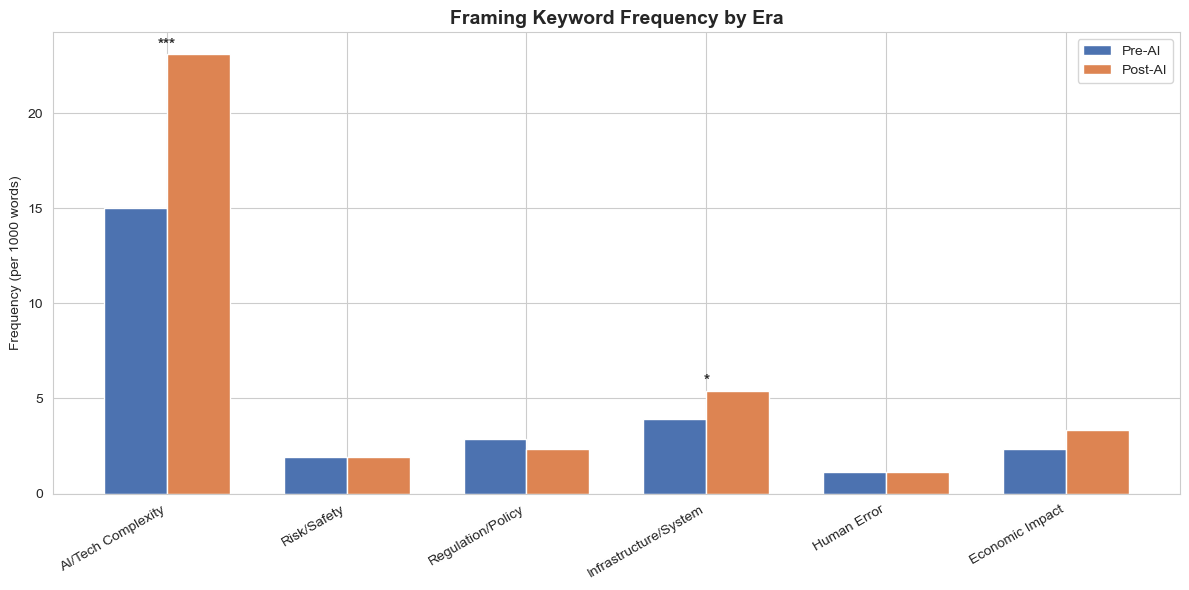

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(framing_categories))
width = 0.35

bars1 = ax.bar(x - width/2, df_kw_results["pre_ai_mean"], width,
               label="Pre-AI", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2, df_kw_results["post_ai_mean"], width,
               label="Post-AI", color="#DD8452", edgecolor="white")

for i, row in df_kw_results.iterrows():
    if row["sig"] != "n.s.":
        max_val = max(row["pre_ai_mean"], row["post_ai_mean"])
        ax.text(i, max_val + 0.3, row["sig"], ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Frequency (per 1000 words)")
ax.set_title("Framing Keyword Frequency by Era", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(framing_categories.keys(), rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_keyword_frequency_clean.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 3. Agency Analysis

Who/what does media blame? Patterns of responsibility attribution.

In [21]:
# ============================================================
# CELL 6: Agency/Blame Attribution — Compute
# ============================================================

agency_frames = {
    "company_blame": [
        "blamed", "fault", "responsible", "negligence", "negligent",
        "failure to", "should have", "could have prevented",
        "apologize", "apologised", "sorry", "admitted",
        "accountability", "liable", "lawsuit",
    ],
    "systemic_risk": [
        "single point of failure", "monoculture", "concentration",
        "too big", "monopoly", "oligopoly", "dependency", "dependent",
        "fragility", "fragile", "interconnected", "cascading",
        "systemic", "infrastructure risk", "centrali",
    ],
    "technical_framing": [
        "configuration change", "software update", "bug", "patch",
        "technical issue", "routine maintenance", "deployment",
        "code", "protocol", "dns", "bgp", "routing", "server",
    ],
    "reassurance": [
        "resolved", "restored", "back online", "fixed", "recovered",
        "back to normal", "working again", "steps to prevent",
        "not a cyberattack", "no malicious", "not a security",
    ],
    "user_impact": [
        "users", "customers", "millions of", "couldn't access",
        "unable to", "stranded", "frustrated", "chaos",
        "disrupted lives", "affected", "impacted",
    ],
    "regulation_call": [
        "regulate", "regulation", "oversight", "congress",
        "parliament", "government should", "antitrust",
        "break up", "competition", "policy response",
    ],
}

# Drop old agency columns if re-running
old_agency_cols = [c for c in df_gd.columns if c.startswith("agency_") or c.startswith("has_")]
if old_agency_cols:
    df_gd = df_gd.drop(columns=old_agency_cols)

for frame, keywords in agency_frames.items():
    df_gd[f"agency_{frame}"] = df_gd["text_for_analysis"].apply(
        lambda t: count_keywords(t, keywords)
    )
    df_gd[f"has_{frame}"] = df_gd[f"agency_{frame}"] > 0

print("Agency frames computed.")


Agency frames computed.


In [22]:
# ============================================================
# CELL 7: Agency Frame Prevalence (% of articles)
# ============================================================

print("=" * 70)
print("AGENCY FRAME PREVALENCE (% of articles containing frame)")
print("=" * 70)

agency_results = []
for frame in agency_frames:
    col = f"has_{frame}"
    pre_pct = df_gd[df_gd["era"] == "pre_ai"][col].mean() * 100
    post_pct = df_gd[df_gd["era"] == "post_ai"][col].mean() * 100

    pre_n = len(df_gd[df_gd["era"] == "pre_ai"])
    post_n = len(df_gd[df_gd["era"] == "post_ai"])
    pre_hits = int(df_gd[df_gd["era"] == "pre_ai"][col].sum())
    post_hits = int(df_gd[df_gd["era"] == "post_ai"][col].sum())

    contingency = [[pre_hits, pre_n - pre_hits],
                   [post_hits, post_n - post_hits]]
    try:
        chi2, p_val, _, _ = stats.chi2_contingency(contingency)
        p_val = float(p_val)
        chi2 = float(chi2)
    except ValueError:
        chi2, p_val = 0, 1.0

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."

    agency_results.append({
        "frame": frame,
        "pre_ai_%": pre_pct,
        "post_ai_%": post_pct,
        "diff_pp": post_pct - pre_pct,
        "chi2": chi2,
        "p_value": p_val,
        "sig": sig,
    })

df_agency_results = pd.DataFrame(agency_results)
print(df_agency_results.to_string(index=False, float_format="%.2f"))


AGENCY FRAME PREVALENCE (% of articles containing frame)
            frame  pre_ai_%  post_ai_%  diff_pp  chi2  p_value  sig
    company_blame     41.41      40.46    -0.96  0.00     0.99 n.s.
    systemic_risk     31.31      27.48    -3.83  0.24     0.63 n.s.
technical_framing     30.30      32.82     2.52  0.07     0.79 n.s.
      reassurance     20.20      19.08    -1.12  0.00     0.97 n.s.
      user_impact     60.61      58.78    -1.83  0.02     0.89 n.s.
  regulation_call     30.30      19.85   -10.46  2.80     0.09 n.s.


In [23]:
# ============================================================
# CELL 8: Agency Frame Intensity (per 1000 words)
# ============================================================

print("=" * 70)
print("AGENCY FRAME INTENSITY (freq per 1000 words)")
print("=" * 70)

intensity_results = []
for frame in agency_frames:
    col = f"agency_{frame}"
    pre_vals = df_gd[df_gd["era"] == "pre_ai"][col]
    post_vals = df_gd[df_gd["era"] == "post_ai"][col]

    u_stat, p_val = stats.mannwhitneyu(pre_vals, post_vals, alternative="two-sided")
    p_val = float(p_val)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."

    intensity_results.append({
        "frame": frame,
        "pre_ai_mean": pre_vals.mean(),
        "post_ai_mean": post_vals.mean(),
        "diff": post_vals.mean() - pre_vals.mean(),
        "p_value": p_val,
        "sig": sig,
    })

df_intensity = pd.DataFrame(intensity_results)
print(df_intensity.to_string(index=False, float_format="%.3f"))


AGENCY FRAME INTENSITY (freq per 1000 words)
            frame  pre_ai_mean  post_ai_mean   diff  p_value  sig
    company_blame        0.769         0.794  0.025    0.723 n.s.
    systemic_risk        0.590         0.663  0.074    0.622 n.s.
technical_framing        1.190         1.000 -0.190    0.654 n.s.
      reassurance        0.430         0.571  0.140    0.970 n.s.
      user_impact        2.921         3.503  0.582    0.469 n.s.
  regulation_call        0.751         0.585 -0.165    0.109 n.s.


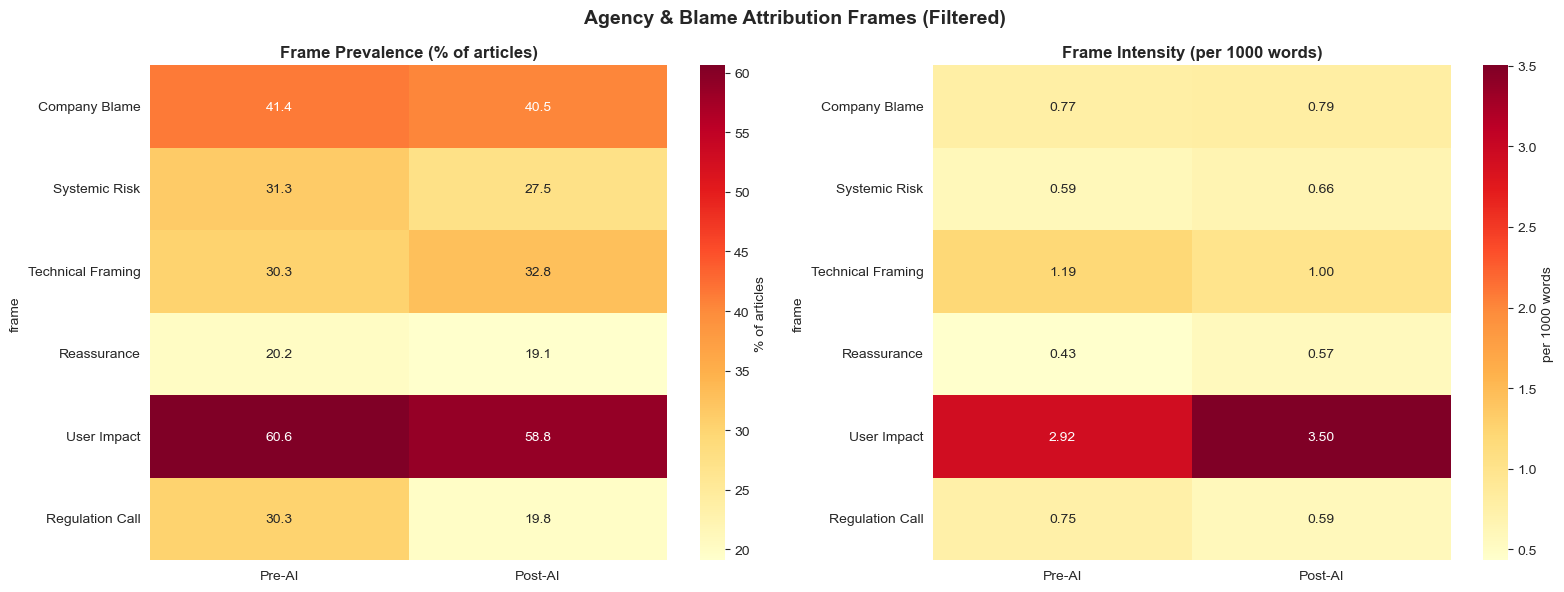

In [24]:
# ============================================================
# CELL 9: Agency Heatmap
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Prevalence
prev_data = df_agency_results[["frame", "pre_ai_%", "post_ai_%"]].set_index("frame")
prev_data.columns = ["Pre-AI", "Post-AI"]
sns.heatmap(prev_data, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"label": "% of articles"})
axes[0].set_title("Frame Prevalence (% of articles)", fontweight="bold")
axes[0].set_yticklabels([f.replace("_", " ").title() for f in prev_data.index], rotation=0)

# Right: Intensity
int_data = df_intensity[["frame", "pre_ai_mean", "post_ai_mean"]].set_index("frame")
int_data.columns = ["Pre-AI", "Post-AI"]
sns.heatmap(int_data, annot=True, fmt=".2f", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "per 1000 words"})
axes[1].set_title("Frame Intensity (per 1000 words)", fontweight="bold")
axes[1].set_yticklabels([f.replace("_", " ").title() for f in int_data.index], rotation=0)

plt.suptitle("Agency & Blame Attribution Frames (Filtered)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_agency_heatmap_clean.png", dpi=150, bbox_inches="tight")
plt.show()



FRAME PREVALENCE BY EVENT (% of articles)
                           has_company_blame  has_systemic_risk  \
era     event                                                     
post_ai aws_2025                        32.1               39.3   
        azure_2025                       0.0               50.0   
        crowdstrike_2024                51.9               25.9   
        google_cloud_2025               34.0               21.3   
pre_ai  aws_2021                         0.0                0.0   
        facebook_2021                   37.3               26.7   
        fastly_2021                     61.1               50.0   
        google_2020                     40.0               40.0   

                           has_technical_framing  has_reassurance  \
era     event                                                       
post_ai aws_2025                            35.7             21.4   
        azure_2025                           0.0              0.0   
        cro

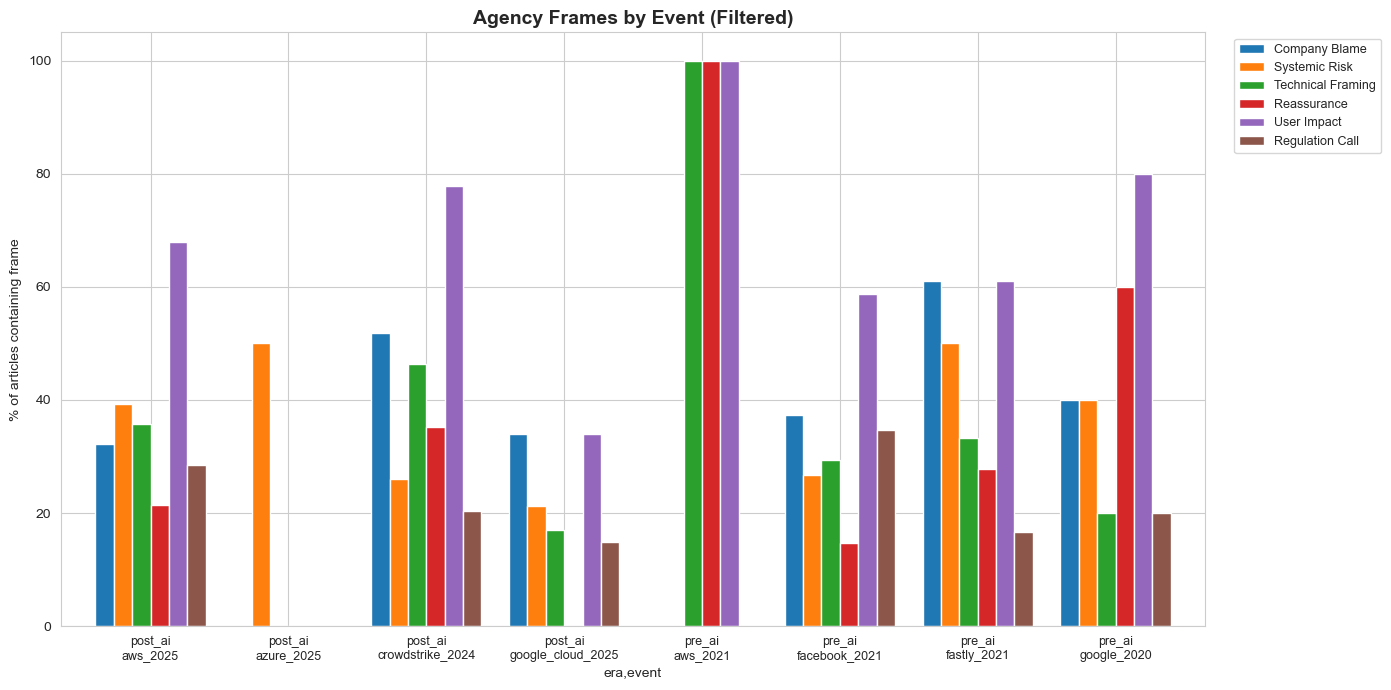

In [25]:

# ============================================================
# CELL 10: Agency by Event — Bar Chart
# ============================================================

frame_cols = [f"has_{frame}" for frame in agency_frames]
event_frame = df_gd.groupby(["era", "event"])[frame_cols].mean() * 100

print("=" * 70)
print("FRAME PREVALENCE BY EVENT (% of articles)")
print("=" * 70)
print(event_frame.round(1))

fig, ax = plt.subplots(figsize=(14, 7))
event_frame.columns = [c.replace("has_", "").replace("_", " ").title() for c in event_frame.columns]
event_frame.plot(kind="bar", ax=ax, edgecolor="white", width=0.8)
ax.set_ylabel("% of articles containing frame")
ax.set_title("Agency Frames by Event (Filtered)", fontsize=14, fontweight="bold")
ax.set_xticklabels([f"{era}\n{event}" for era, event in event_frame.index],
                    rotation=0, fontsize=9)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_agency_by_event_clean.png", dpi=150, bbox_inches="tight")
plt.show()



---
## 4. Summary & Export

In [26]:
df_tfidf.to_csv(f"{OUT_DIR}/tfidf_results_clean.csv", index=False)
df_kw_results.to_csv(f"{OUT_DIR}/keyword_frequency_results_clean.csv", index=False)
df_agency_results.to_csv(f"{OUT_DIR}/agency_prevalence_results_clean.csv", index=False)
df_intensity.to_csv(f"{OUT_DIR}/agency_intensity_results_clean.csv", index=False)
df_gd.to_csv(f"{OUT_DIR}/guardian_analyzed_clean.csv", index=False)

print("All CSVs saved.")

print("\n" + "=" * 60)
print("KEY FINDINGS SUMMARY (FILTERED)")
print("=" * 60)

# TF-IDF top words
top3_post = df_tfidf.nlargest(3, "diff")["word"].tolist()
top3_pre = df_tfidf.nsmallest(3, "diff")["word"].tolist()
print(f"\n1. VOCABULARY (event names removed)")
print(f"   Most Post-AI: {', '.join(top3_post)}")
print(f"   Most Pre-AI: {', '.join(top3_pre)}")

# Significant keywords
print(f"\n2. FRAMING KEYWORDS")
sig_kw = df_kw_results[df_kw_results["sig"] != "n.s."]
if len(sig_kw) > 0:
    for _, row in sig_kw.iterrows():
        direction = "↑" if row["diff"] > 0 else "↓"
        print(f"   {direction} {row['category']}: pre={row['pre_ai_mean']:.2f}, post={row['post_ai_mean']:.2f} ({row['sig']})")
else:
    print("   No significant differences found.")

# Significant agency
print(f"\n3. AGENCY/BLAME FRAMES (prevalence)")
sig_ag = df_agency_results[df_agency_results["sig"] != "n.s."]
if len(sig_ag) > 0:
    for _, row in sig_ag.iterrows():
        direction = "↑" if row["diff_pp"] > 0 else "↓"
        print(f"   {direction} {row['frame']}: pre={row['pre_ai_%']:.1f}%, post={row['post_ai_%']:.1f}% ({row['sig']})")
else:
    print("   No significant differences found.")

# Significant agency intensity
print(f"\n4. AGENCY/BLAME FRAMES (intensity)")
sig_int = df_intensity[df_intensity["sig"] != "n.s."]
if len(sig_int) > 0:
    for _, row in sig_int.iterrows():
        direction = "↑" if row["diff"] > 0 else "↓"
        print(f"   {direction} {row['frame']}: pre={row['pre_ai_mean']:.2f}, post={row['post_ai_mean']:.2f} ({row['sig']})")
else:
    print("   No significant differences found.")

print(f"\n{'=' * 60}")


All CSVs saved.

KEY FINDINGS SUMMARY (FILTERED)

1. VOCABULARY (event names removed)
   Most Post-AI: ai, said, update
   Most Pre-AI: social, fastly, media

2. FRAMING KEYWORDS
   ↑ AI/Tech Complexity: pre=15.01, post=23.11 (***)
   ↑ Infrastructure/System: pre=3.95, post=5.41 (*)

3. AGENCY/BLAME FRAMES (prevalence)
   No significant differences found.

4. AGENCY/BLAME FRAMES (intensity)
   No significant differences found.

